In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt

from keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer


In [3]:
max_words = 10000
maxlen = 150


In [4]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_words)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

# Validation set (10,000 samples)
x_val = x_test[:10000]
y_val = y_test[:10000]


In [5]:
def build_learned_embedding_model():
    model = Sequential([
        Embedding(max_words, 32, input_length=maxlen),
        LSTM(32),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [6]:
def load_glove_embeddings(glove_path="glove.6B.100d.txt"):
    embeddings_index = {}
    with open(glove_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coeffs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coeffs
    return embeddings_index


def build_pretrained_embedding_matrix(word_index, embeddings_index):
    embedding_dim = 100
    embedding_matrix = np.zeros((max_words, embedding_dim))
    
    for word, i in word_index.items():
        if i < max_words:
            embedding_vector = embeddings_index.get(word)
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector
    
    return embedding_matrix



In [7]:
def build_glove_model(embedding_matrix):
    model = Sequential([
        Embedding(
            max_words,
            100,
            weights=[embedding_matrix],
            input_length=maxlen,
            trainable=False
        ),
        LSTM(32),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [8]:
glove_path = r"C:\Users\12162\Downloads\glove.6B.100d.txt"


In [9]:
def load_glove_embeddings(glove_path):
    embeddings_index = {}
    with open(glove_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coeffs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coeffs
    return embeddings_index


def build_embedding_matrix(word_index, embeddings_index):
    embedding_dim = 100
    embedding_matrix = np.zeros((max_words, embedding_dim))
    
    for word, i in word_index.items():
        if i < max_words:
            vector = embeddings_index.get(word)
            if vector is not None:
                embedding_matrix[i] = vector
                
    return embedding_matrix


In [10]:
def build_glove_model(embedding_matrix):
    model = Sequential([
        Embedding(
            max_words,
            100,
            weights=[embedding_matrix],
            input_length=maxlen,
            trainable=False
        ),
        LSTM(32),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model


In [11]:
import os 
import numpy as np
print("Checking GloVe file...")
if not os.path.exists(glove_path):
    raise FileNotFoundError(" GloVe file not found. Check your path.")

print("Loading GloVe embeddings (this may take a minute)...")
embeddings_index = load_glove_embeddings(glove_path)

print("Building embedding matrix...")
word_index = imdb.get_word_index()
embedding_matrix = build_embedding_matrix(word_index, embeddings_index)

Checking GloVe file...
Loading GloVe embeddings (this may take a minute)...
Building embedding matrix...


In [12]:
train_sizes = [100, 500, 1000, 5000]

learned_results = []
glove_results = []

for size in train_sizes:
    print(f"\nTraining with {size} samples...\n")
    
    x_small = x_train[:size]
    y_small = y_train[:size]


Training with 100 samples...


Training with 500 samples...


Training with 1000 samples...


Training with 5000 samples...



In [17]:
def build_learned_embedding_model():
    model = Sequential([
        Embedding(max_words, 32, input_length=maxlen),
        LSTM(32),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [20]:

model2 = build_glove_model(embedding_matrix)
history2 = model2.fit(
        x_small,
        y_small,
        epochs=5,
        batch_size=32,
        validation_data=(x_val, y_val),
        verbose=0
    )
    
acc2 = history2.history['val_accuracy'][-1]
glove_results.append(acc2)
    
print(f"GloVe Accuracy: {acc2:.4f}")

GloVe Accuracy: 0.5027


In [ ]:
# There is a mismatch in the lengths of the results lists, so we will print them to debug
print(train_sizes)
print(learned_results)
print(glove_results)
print(len(train_sizes), len(learned_results), len(glove_results))

[100, 500, 1000, 5000]
[]
[0.5026999711990356]
4 0 1


In [26]:
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K
import gc

train_sizes = [100, 500, 1000, 5000]

learned_results = []
glove_results = []

for size in train_sizes:
    print(f"\nTraining with {size} samples...")

    x_small = x_train[:size]
    y_small = y_train[:size]

    # Learned embedding
    K.clear_session()
    gc.collect()

    model1 = build_learned_embedding_model()
    history1 = model1.fit(
        x_small,
        y_small,
        epochs=5,
        batch_size=32,
        validation_data=(x_val, y_val),
        verbose=1
    )

    acc1 = history1.history['val_accuracy'][-1]
    learned_results.append(acc1)
    print(f"Learned Embedding Accuracy: {acc1:.4f}")

    # GloVe embedding
    K.clear_session()
    gc.collect()

    model2 = build_glove_model(embedding_matrix)
    history2 = model2.fit(
        x_small,
        y_small,
        epochs=5,
        batch_size=32,
        validation_data=(x_val, y_val),
        verbose=1
    )

    acc2 = history2.history['val_accuracy'][-1]
    glove_results.append(acc2)
    print(f"GloVe Embedding Accuracy: {acc2:.4f}")


Training with 100 samples...

Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5100 - loss: 0.6931 - val_accuracy: 0.5065 - val_loss: 0.6928
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5800 - loss: 0.6858 - val_accuracy: 0.5055 - val_loss: 0.6926
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5900 - loss: 0.6801 - val_accuracy: 0.5031 - val_loss: 0.6925
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.6100 - loss: 0.6722 - val_accuracy: 0.5042 - val_loss: 0.6922
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6300 - loss: 0.6616 - val_accuracy: 0.5029 - val_loss: 0.6925
Learned Embedding Accuracy: 0.5029
Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.4400 - loss: 0.7031 - val_accuracy: 0.5105 - val_loss: 0.6988
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5500 - loss: 0.6778 - val_accuracy: 0.5025 - val_loss: 0.7264
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5800 - loss: 0.6689 

In [27]:
print(train_sizes)
print(learned_results)
print(glove_results)
print(len(train_sizes), len(learned_results), len(glove_results))

[100, 500, 1000, 5000]
[0.5029000043869019, 0.7243000268936157, 0.6958000063896179, 0.7709000110626221]
[0.5081999897956848, 0.5408999919891357, 0.5235000252723694, 0.5817999839782715]
4 4 4


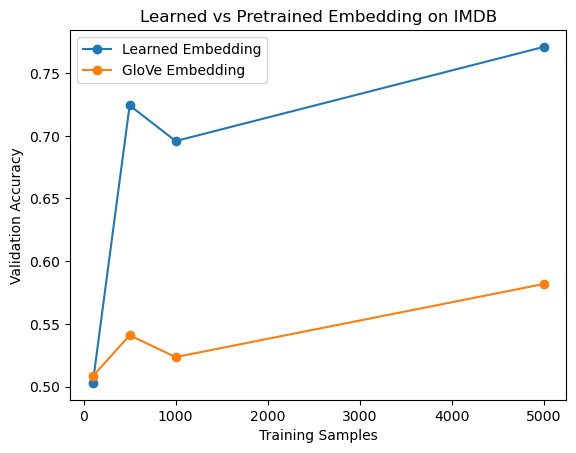

In [28]:
plt.plot(train_sizes, learned_results, marker='o', label='Learned Embedding')
plt.plot(train_sizes, glove_results, marker='o', label='GloVe Embedding')
plt.xlabel('Training Samples')
plt.ylabel('Validation Accuracy')
plt.title('Learned vs Pretrained Embedding on IMDB')
plt.legend()
plt.show()